# PROCESSING HPA

In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import pandas as pd
from packageCYSK.preprocessingCYTO import *
from packageCYSK.importing import *
from packageCYSK.processing import *
from packageCYSK.visualization import *

# Define dataset folder.
folder      = os.getcwd() + "\\data"

# Import images from CYTO, NUCL and RGB folders.
options     = ["CYTO"]

# Dictionary with keys "CYTO", "NUCL", "RGB".
data = init_import(folder,options)

ROIs = pd.read_pickle("ROIs_HPA.pkl")

>>> [CYTO] added.


In [2]:
data['CYTO']

,Path,Name,Label,Label 2,Resolution,Image,Image Size
HPA,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,Cells,abc.tif,"(1, 0.08, 0.08)","[[0, 0, 0, 0, 0, 0, 0, 38, 146, 80, 0, 0, 0, 0...","(2048, 2048)"


In [3]:
ROIs

,Name,Index,Label,Image Size,ROImask
0,Cells_HPA_Cells_abc.tiff,HPA,Cells,"(2048, 2048)","([164, 165, 165, 165, 165, 165, 165, 166, 166,..."


False

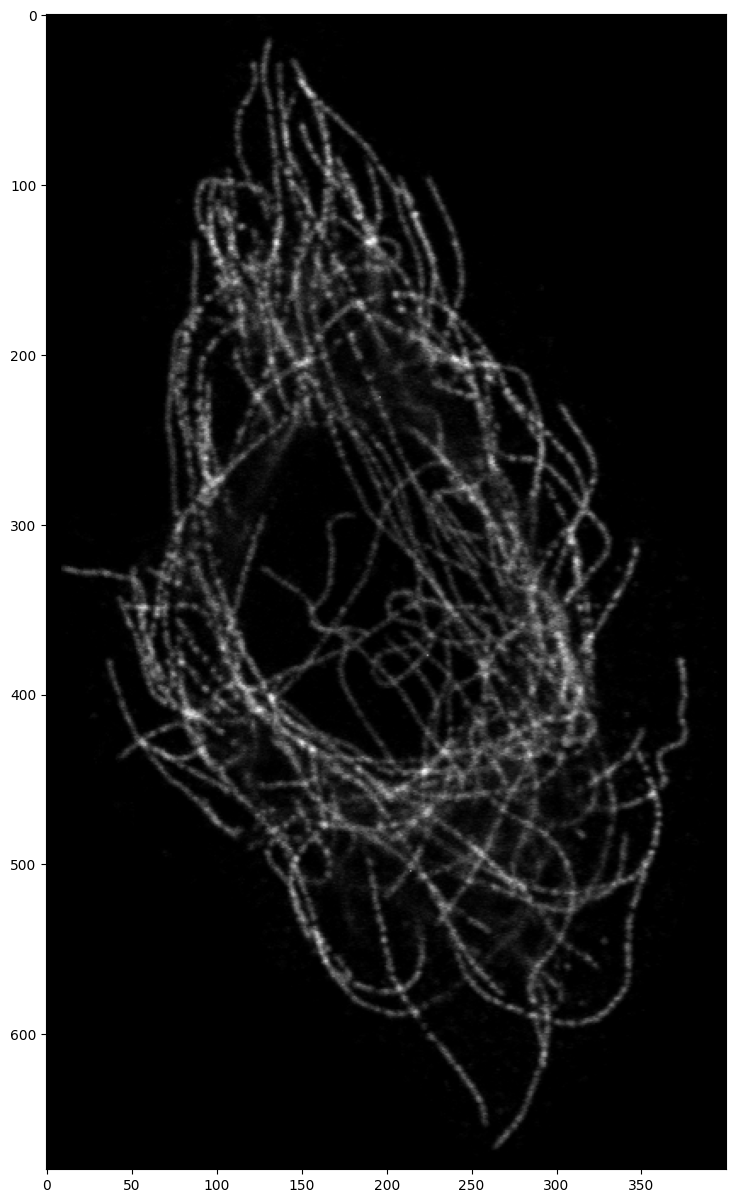

In [4]:
#plt.imshow(ROIs.loc[0]['ROImask'])
imag = data['CYTO'].loc['HPA']['Image'] * retrieve_mask(ROIs.loc[0]['ROImask'],[2048,2048])
imag = imag[180:860,0:400]
plt.figure(figsize=(15,15))
plt.imshow(imag,cmap='gray')
#cv2.imwrite(os.path.join(os.getcwd(),"figs","figs2","original.tif"),(255*imag/np.max(imag)).astype(np.uint8))

False

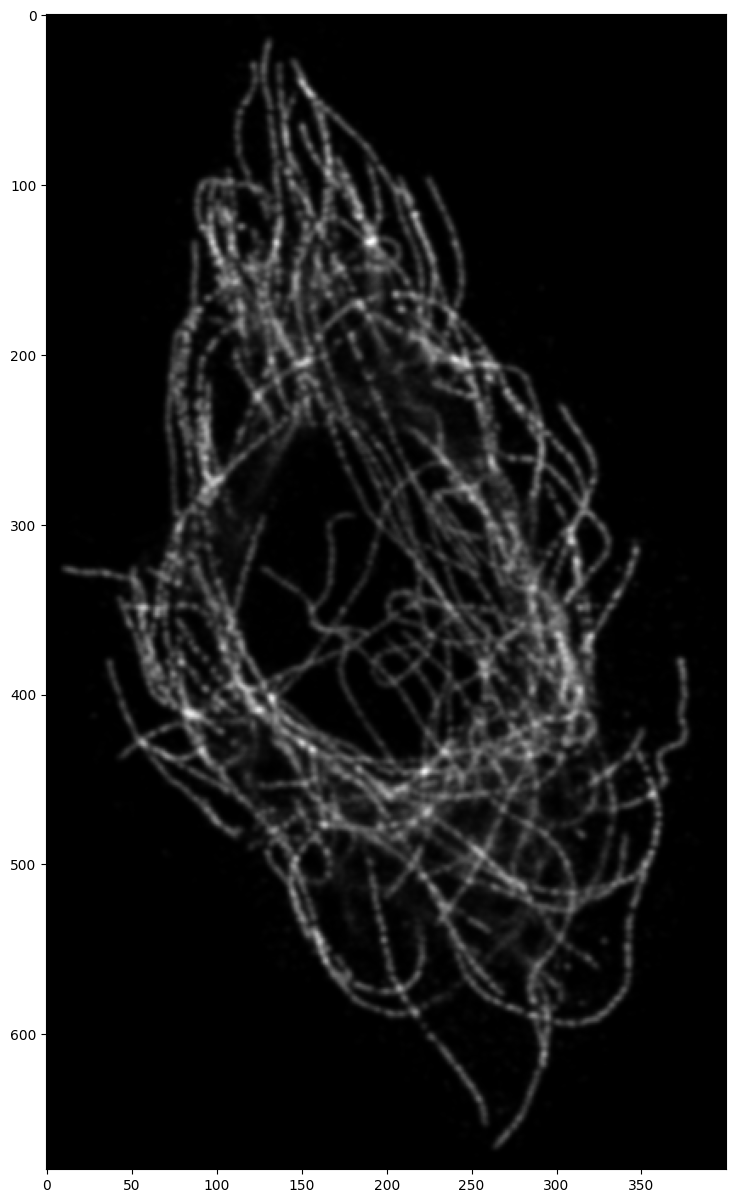

In [5]:
from skimage.filters import gaussian

gau = gaussian(imag, sigma=1)
plt.figure(figsize=(15,15))
plt.imshow(gau,cmap='gray')
cv2.imwrite(os.path.join(os.getcwd(),"figs","figs2","gaussian.tif"),(255*gau/np.max(gau)).astype(np.uint8))

False

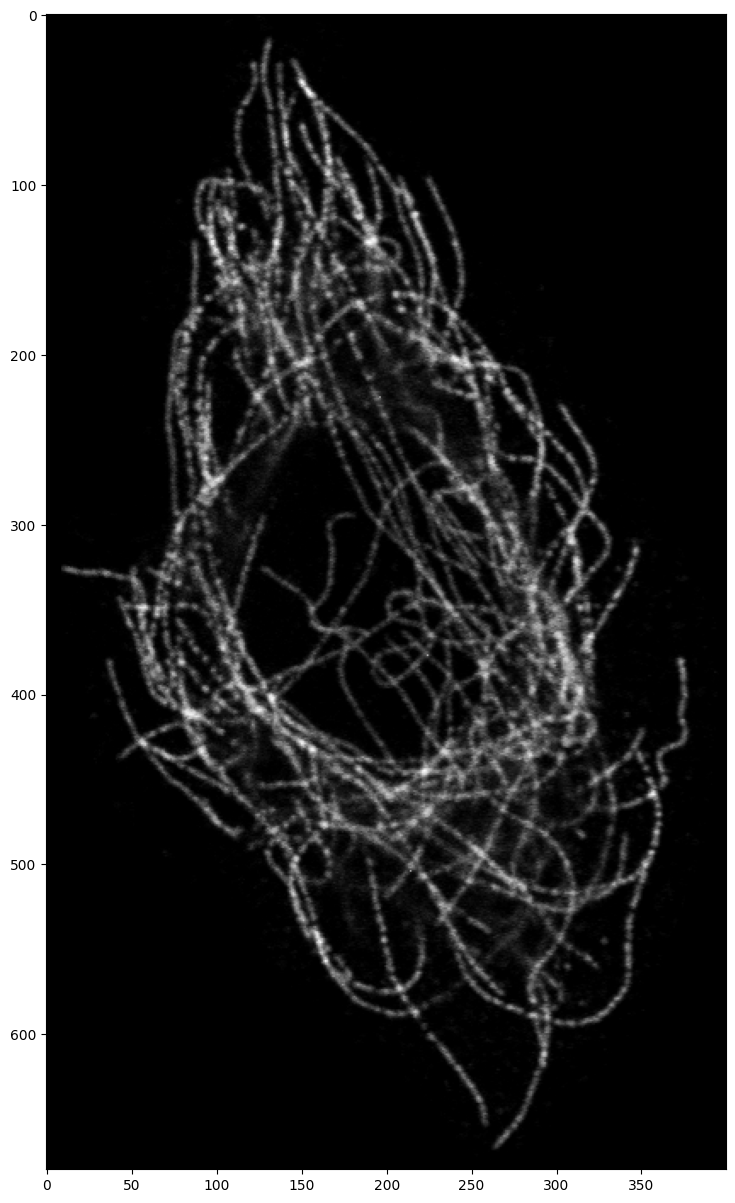

In [6]:
from skimage.exposure import equalize_adapthist

from skimage import img_as_float

clahe_image = equalize_adapthist(imag/np.max(imag), clip_limit=0.005)

plt.figure(figsize=(15,15))
plt.imshow(clahe_image,cmap='gray')
cv2.imwrite(os.path.join(os.getcwd(),"figs","figs2","clahe.tif"),(255*clahe_image/np.max(clahe_image)).astype(np.uint8))

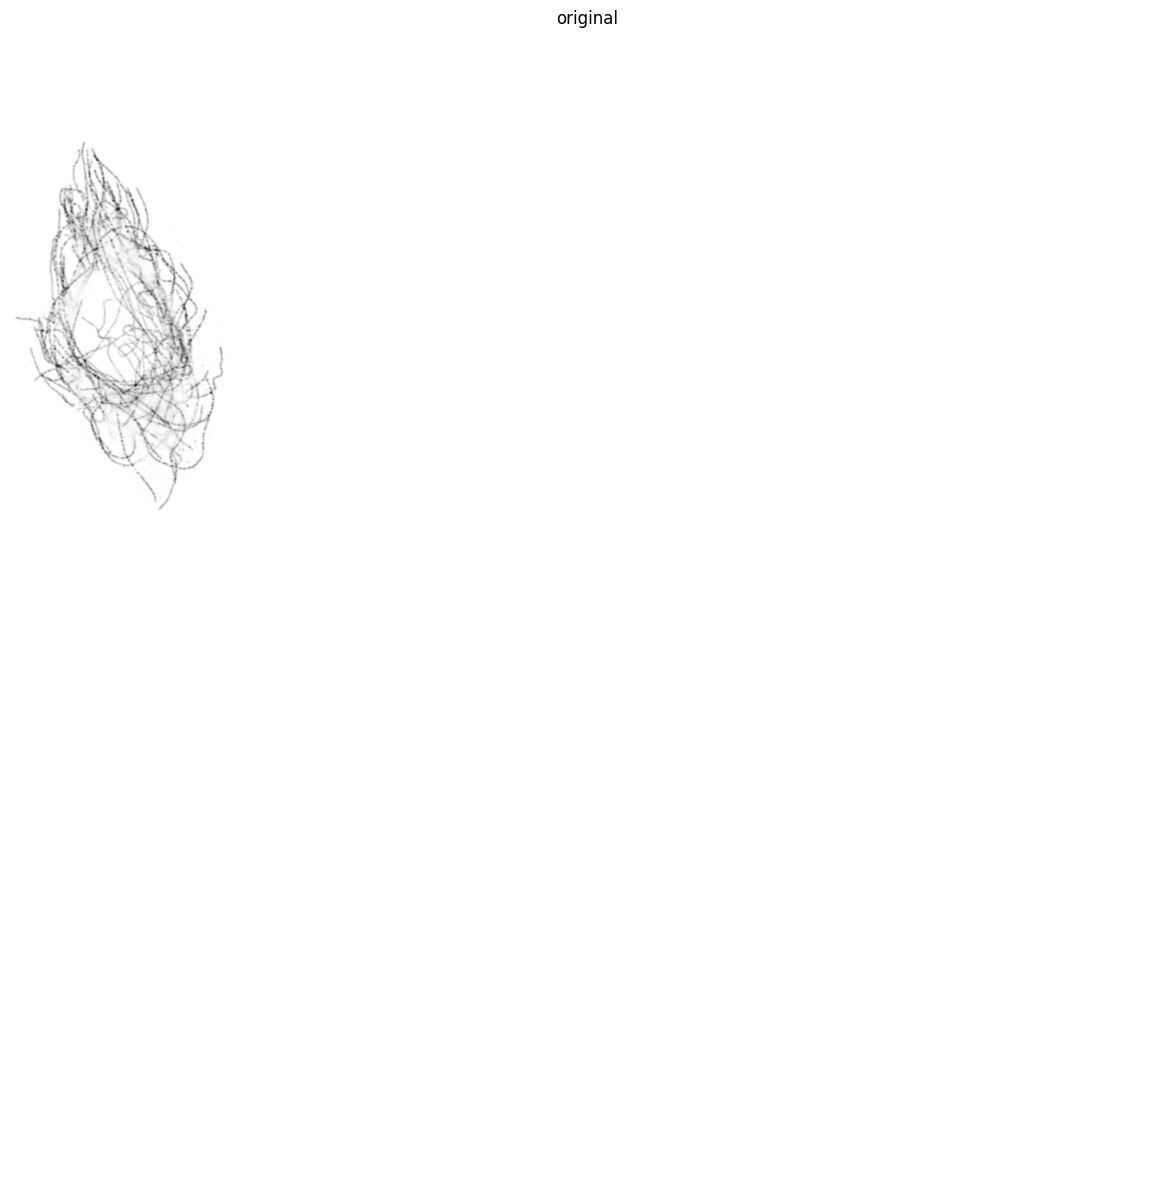

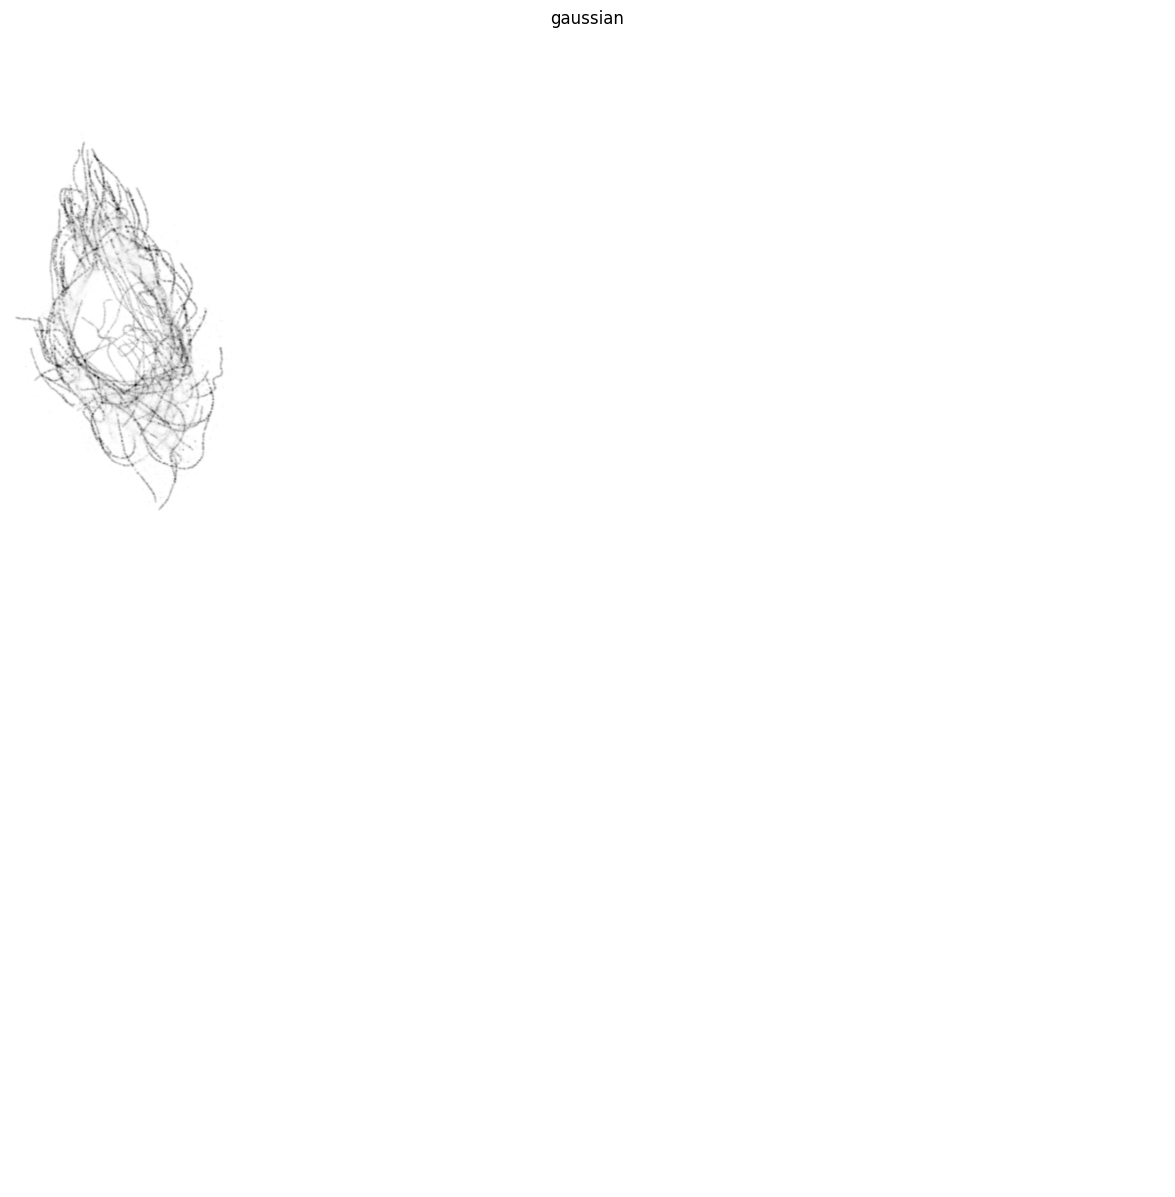

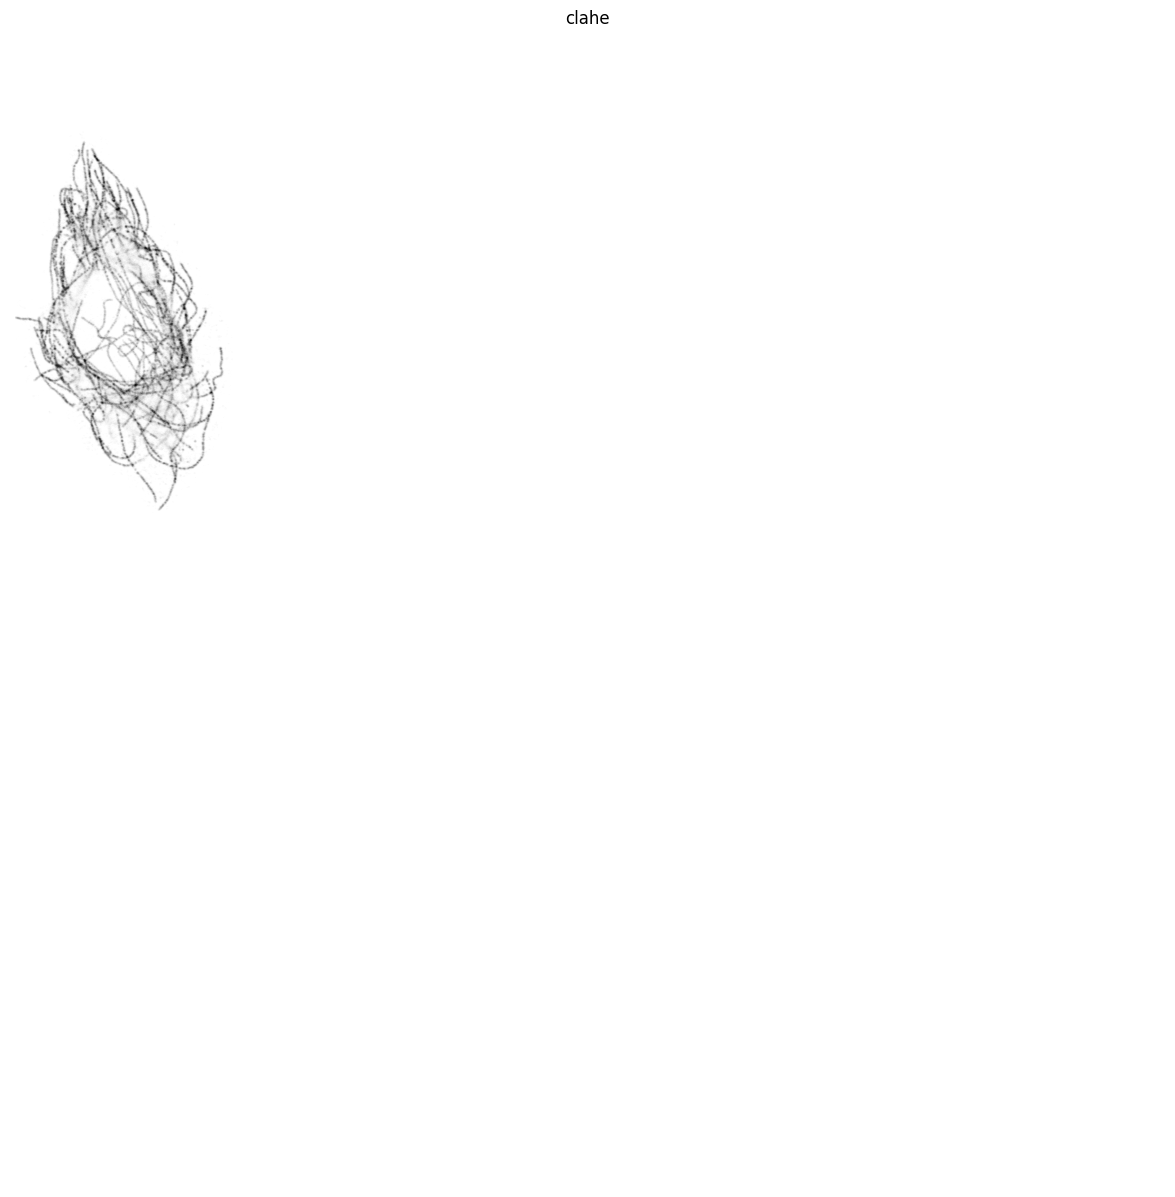

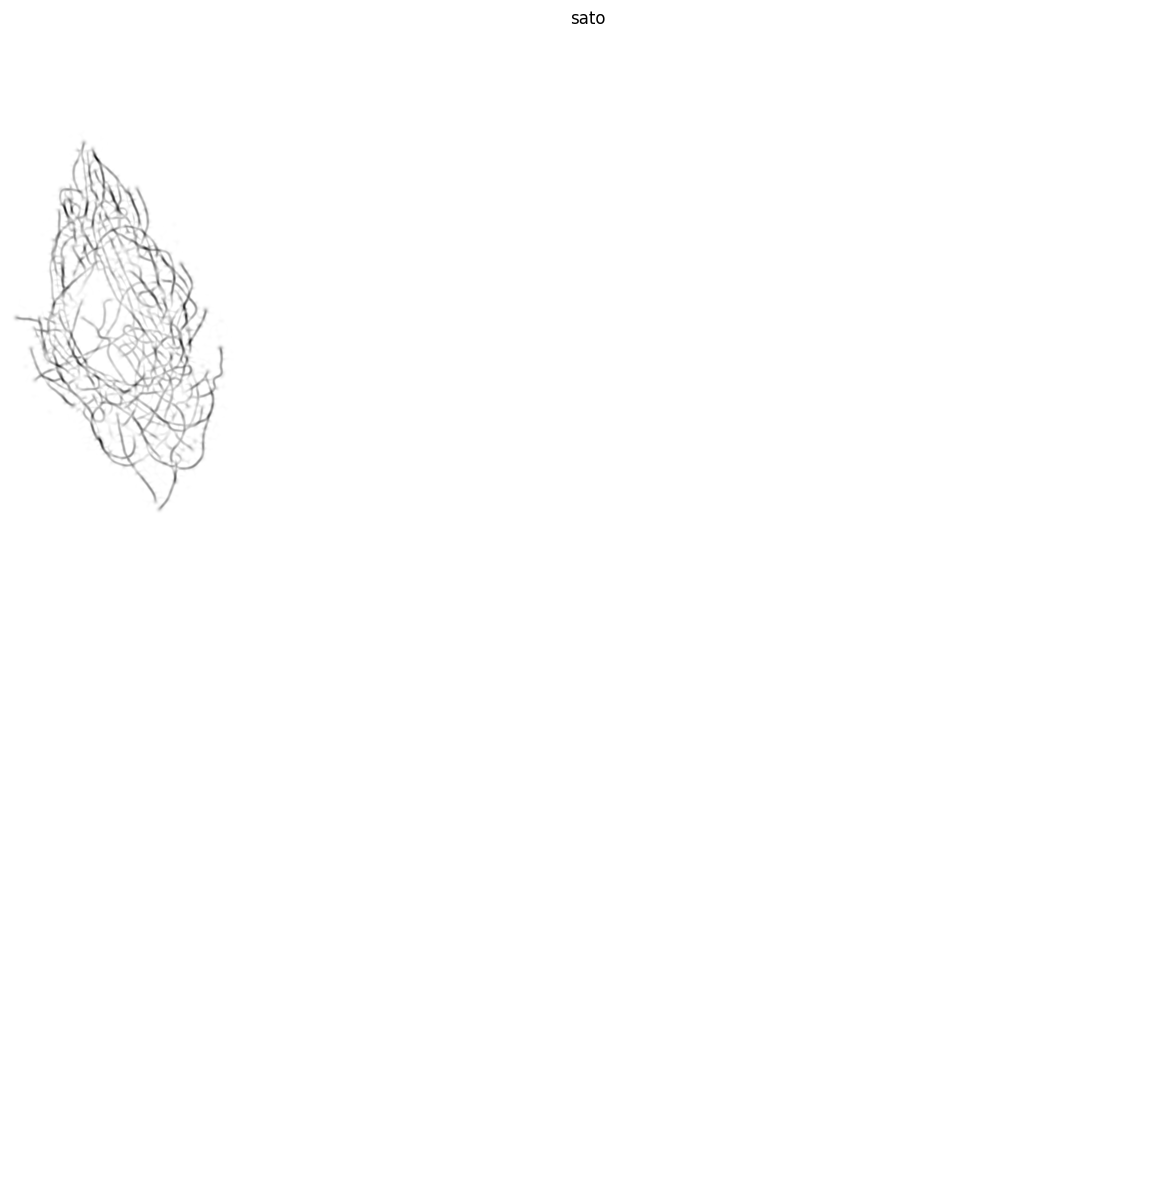

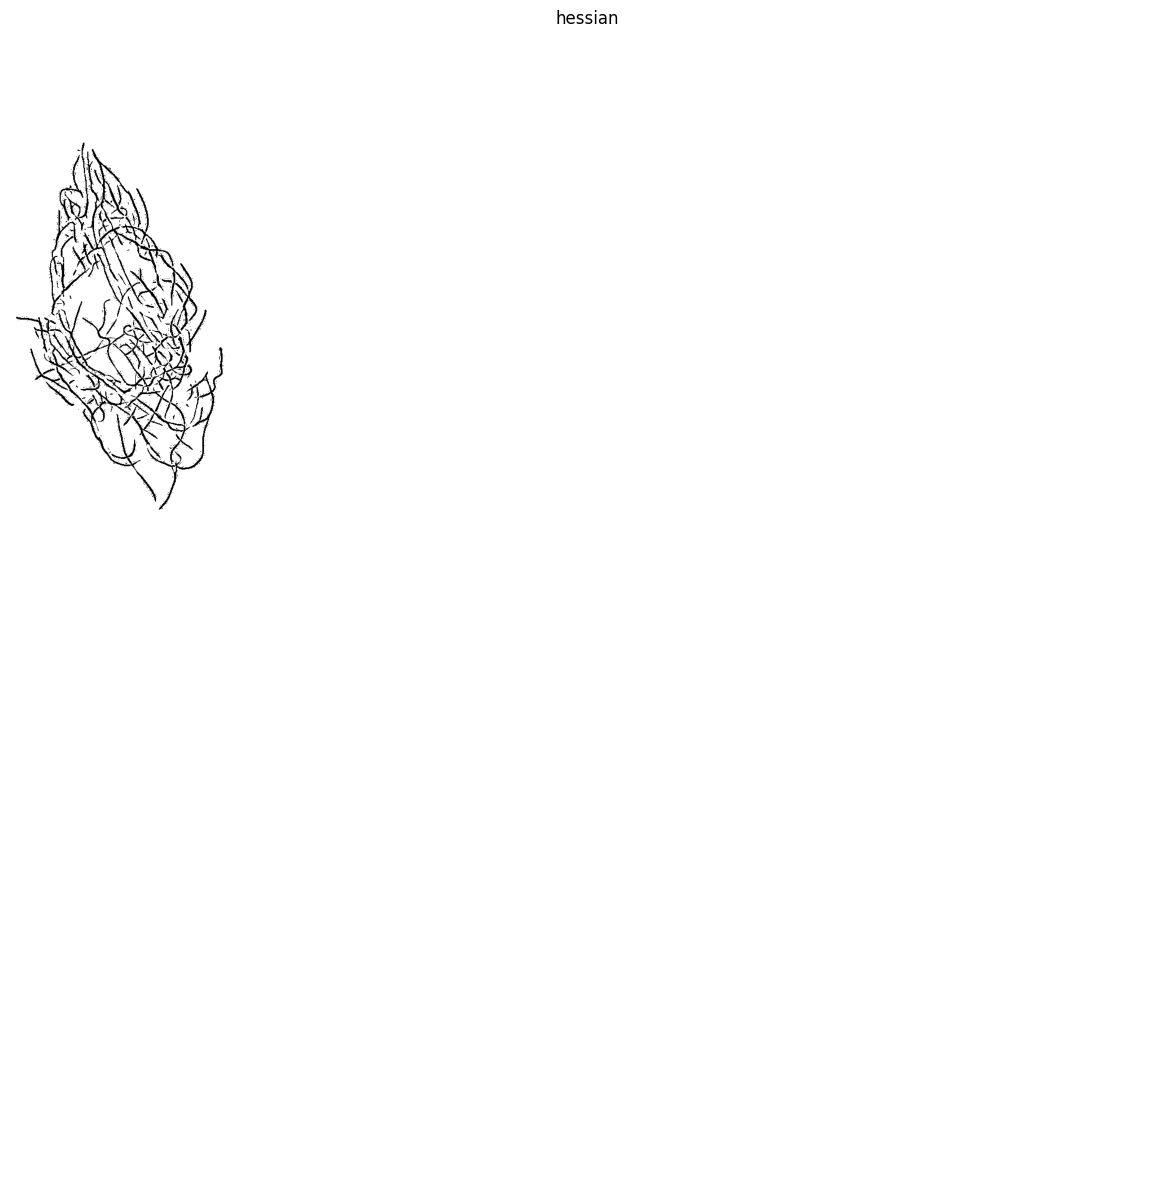

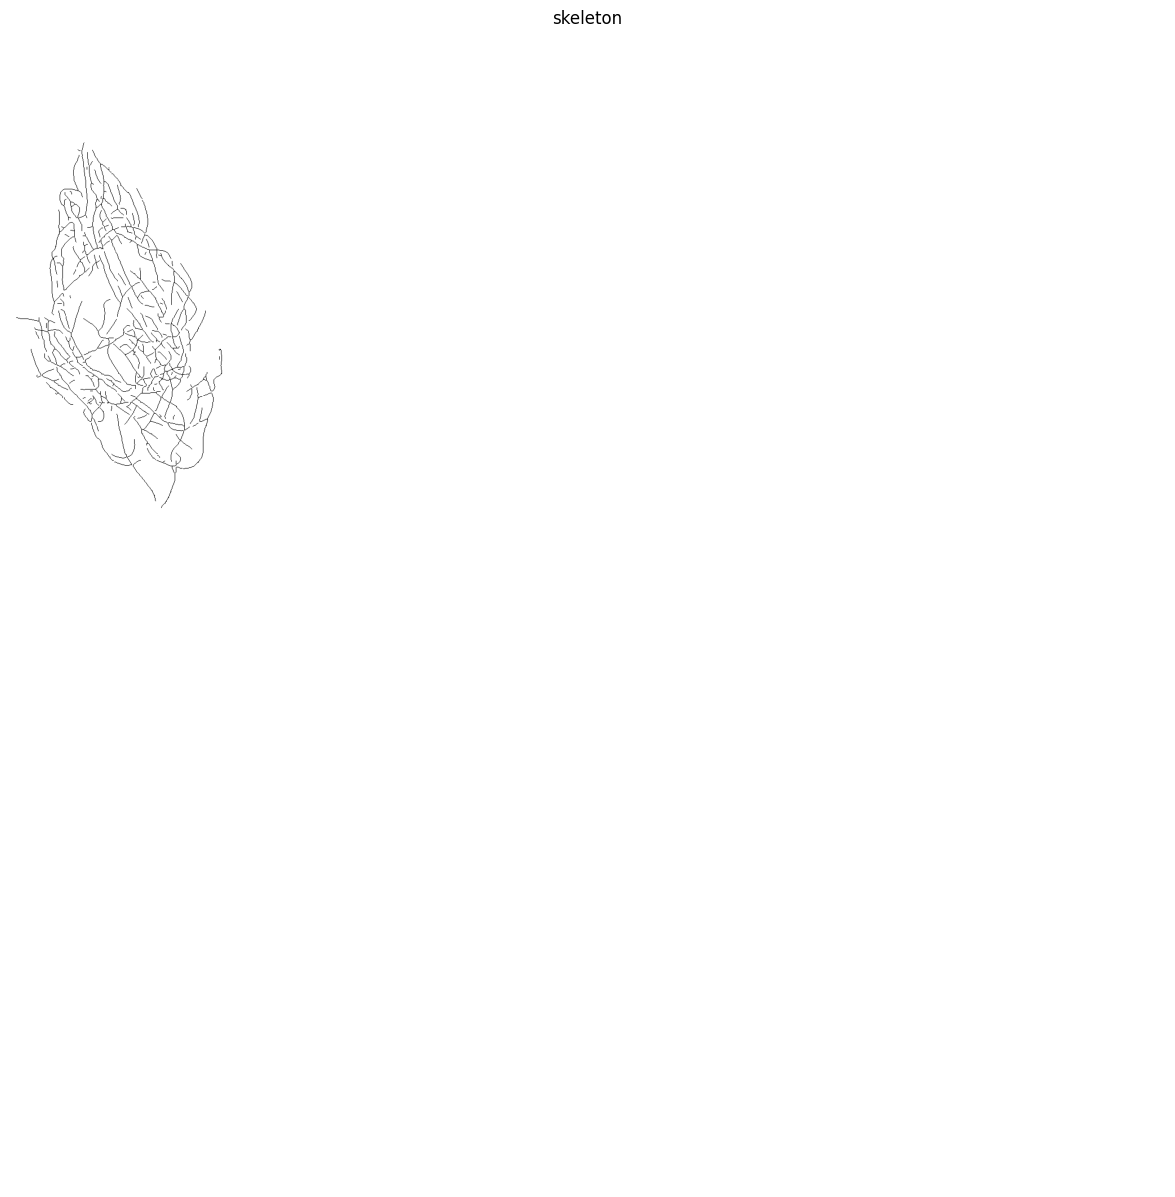

In [4]:

idx = 'HPA'
#temp = data['CYTO'].loc['HPA']['Image'] * retrieve_mask(ROIs.loc[0]['ROImask'],ROIs.loc[0]['Image Size'])
#data['CYTO'].loc['HPA']['Image'] = temp[180:860,0:400]
imag = data['CYTO'].loc['HPA']['Image'] * retrieve_mask(ROIs.loc[0]['ROImask'],[2048,2048])
#imag = imag[180:860,0:400]
data['CYTO'].loc['HPA']['Image'] = imag
data['CYTO_PRE'],imagens = cytoskeleton_preprocessing(rowCYTO = data['CYTO'].loc[idx],
                                           parameters = {'gau_sigma': 0,
                                                         'clahe_clip': 0.005,
                                                         'sato_sigma': 3,
                                                         'hess_sigma': 0.33},
                                                 plot = True,
                                                 save = False) #save=folder+"\\" + str(image_id))

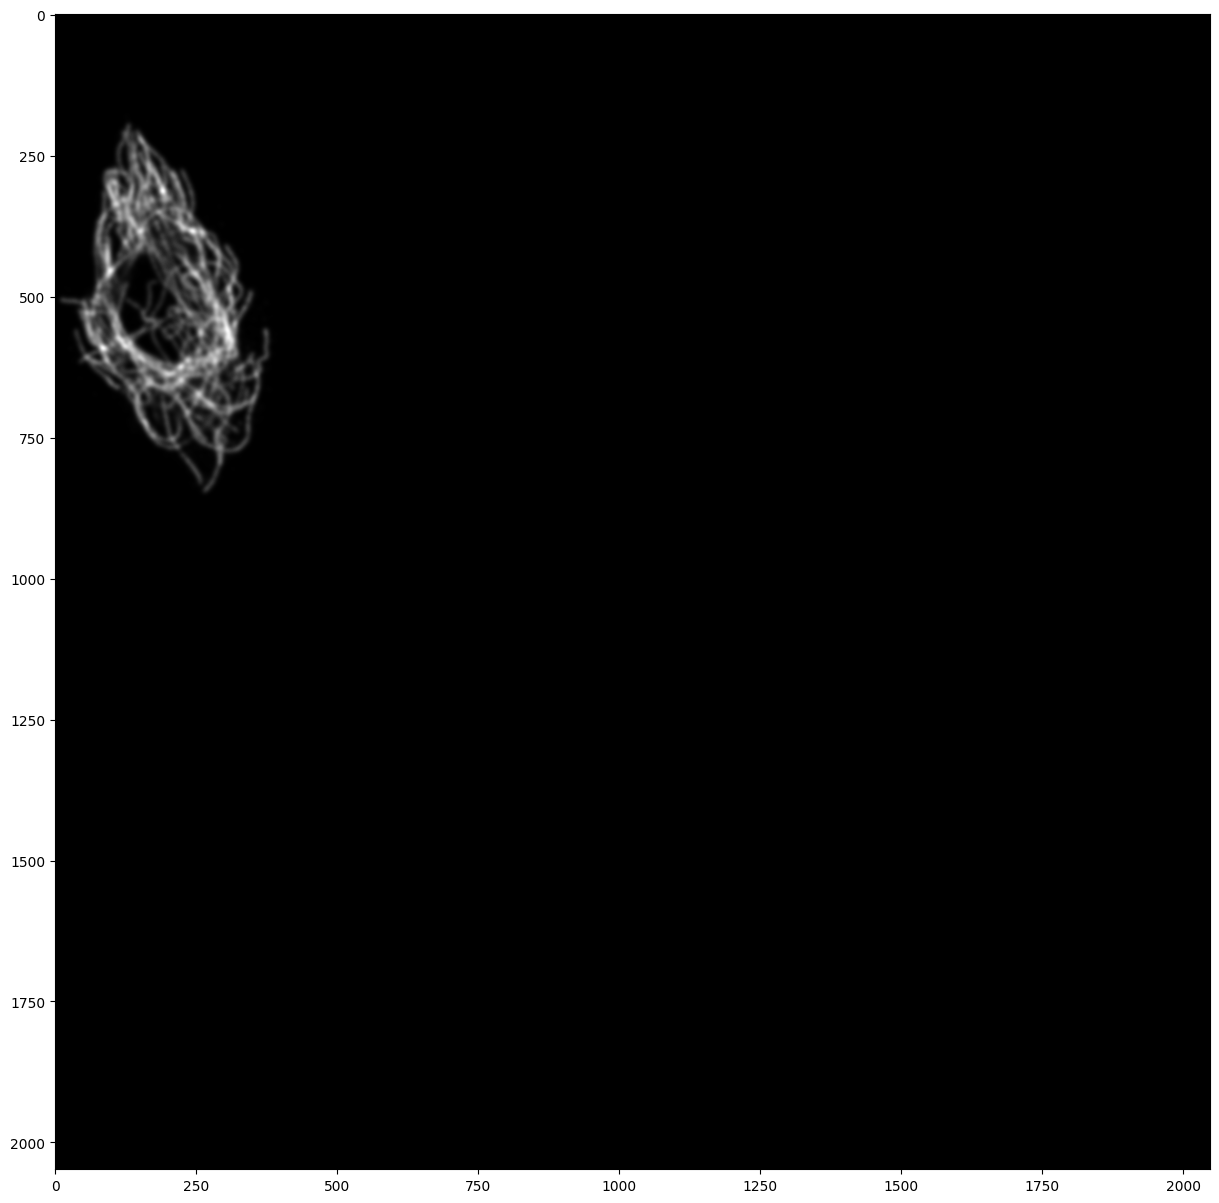

In [5]:
plt.figure(figsize=(15,15))
plt.imshow(imagens[1],cmap='gray')

In [34]:
#plt.figure(figsize=(15,15))
skelorig = imagens[0]*imagens[-1]
skelorig = ((2**16-1)*skelorig).astype(np.uint16)
skelorig = skelorig[180:860,0:400]
#plt.imshow(skelorig,cmap='gray')
#os.path.join(os.getcwd(),"figs","figs2","skelorig.tif")
#cv2.imwrite(os.path.join(os.getcwd(),"figs","figs2","skelorig.tif"),skelorig)
import tifffile as tiffio
tiffio.imwrite(os.path.join(os.getcwd(), "figs", "fig2", "skelorig.tif"), skelorig)


In [31]:
np.max(skelorig)

65535

In [28]:
np.max((2**16)*skelorig)

4230479872

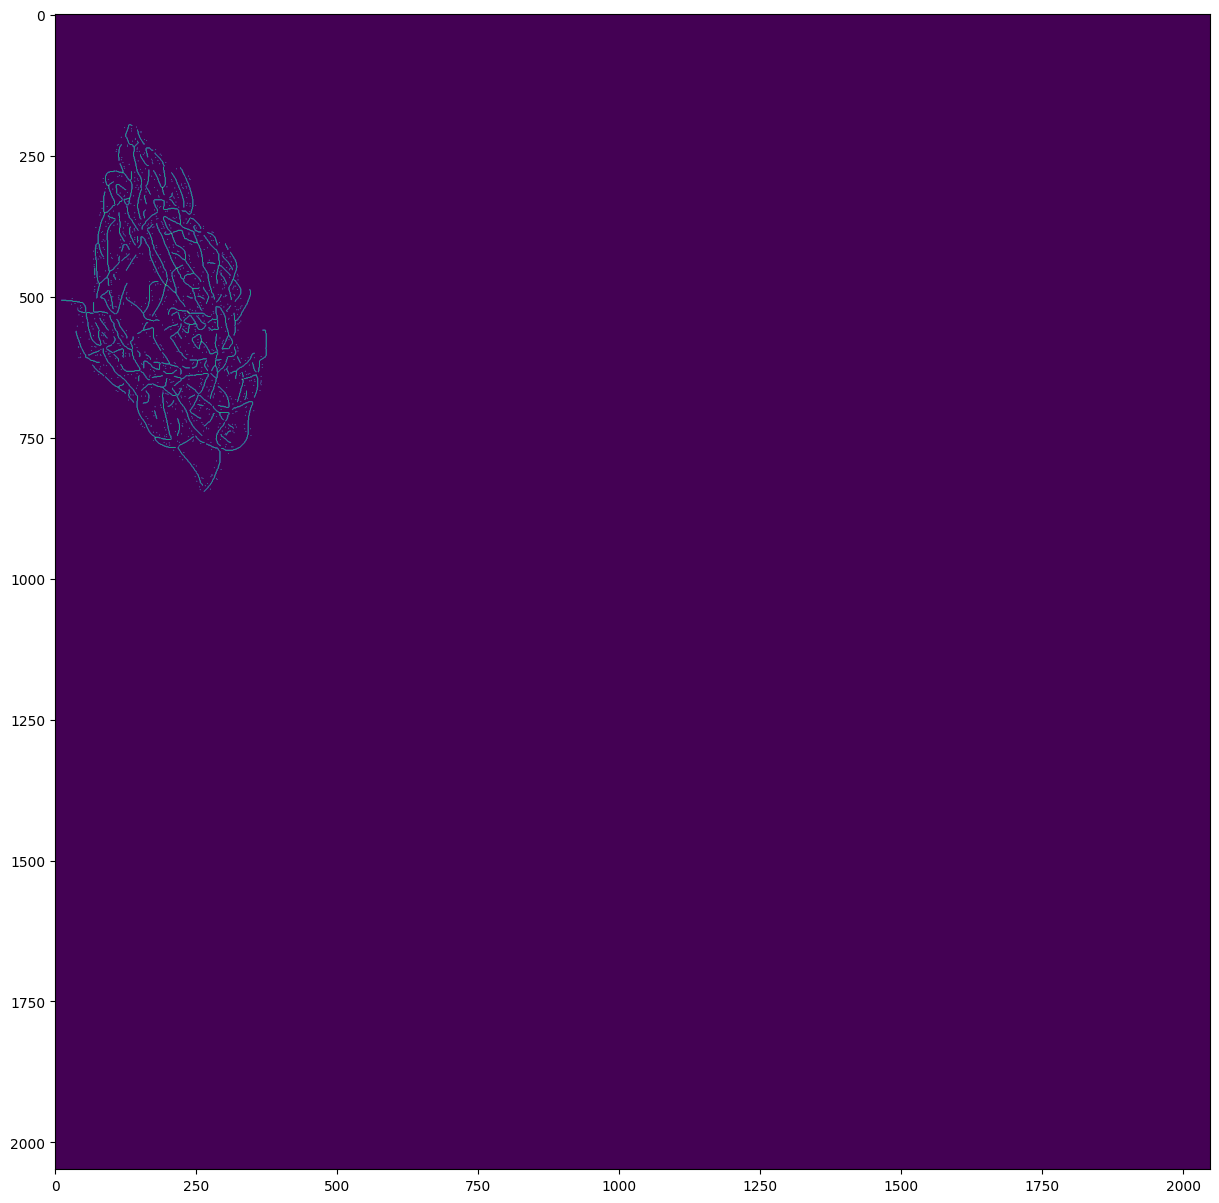

In [4]:
plt.figure(figsize=(15,15))
plt.imshow(imagens[-1])

In [5]:
ResultsDF = processing_cell(rowROI           = ROIs.loc[0],
                            data             = data,
                            LSFparams        = {'res_thr': 4})

ResultsDF

,Path,Name,Img Index,Label,Image Size,Resolution,Mask,Skeleton,Patch:Deconvoluted Cyto,Patch:Skeleton Max,Offset,Lines
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tiff,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([164, 165, 165, 165, 165, 165, 165, 166, 166,...","([196, 197, 198, 199, 200, 201, 202, 203, 204,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[164, 165, 165, 165, 165, 165, 165, 166, 166,...","[((127.741, 196.538), (136.988, 323.462)), ((1..."


(-0.5, 399.5, 679.5, -0.5)

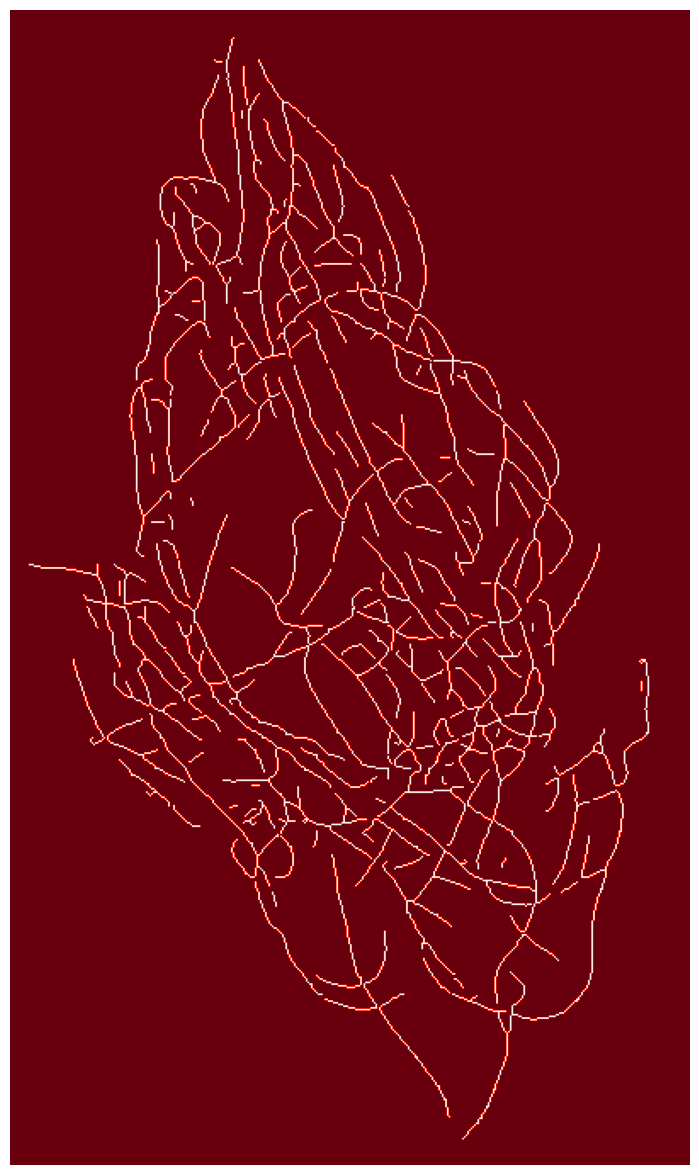

In [37]:
ori = np.max(imagens[0]) - imagens[0]
skelele = imagens[-1]

#stack = np.stack([1.1*ori,np.zeros_like(ori),1*skelele],axis=-1)
plt.figure(figsize=(15,15))
#plt.imshow(ori,cmap='gray')
plt.imshow(skelele, cmap='Reds_r', alpha=1)  

plt.axis('off')

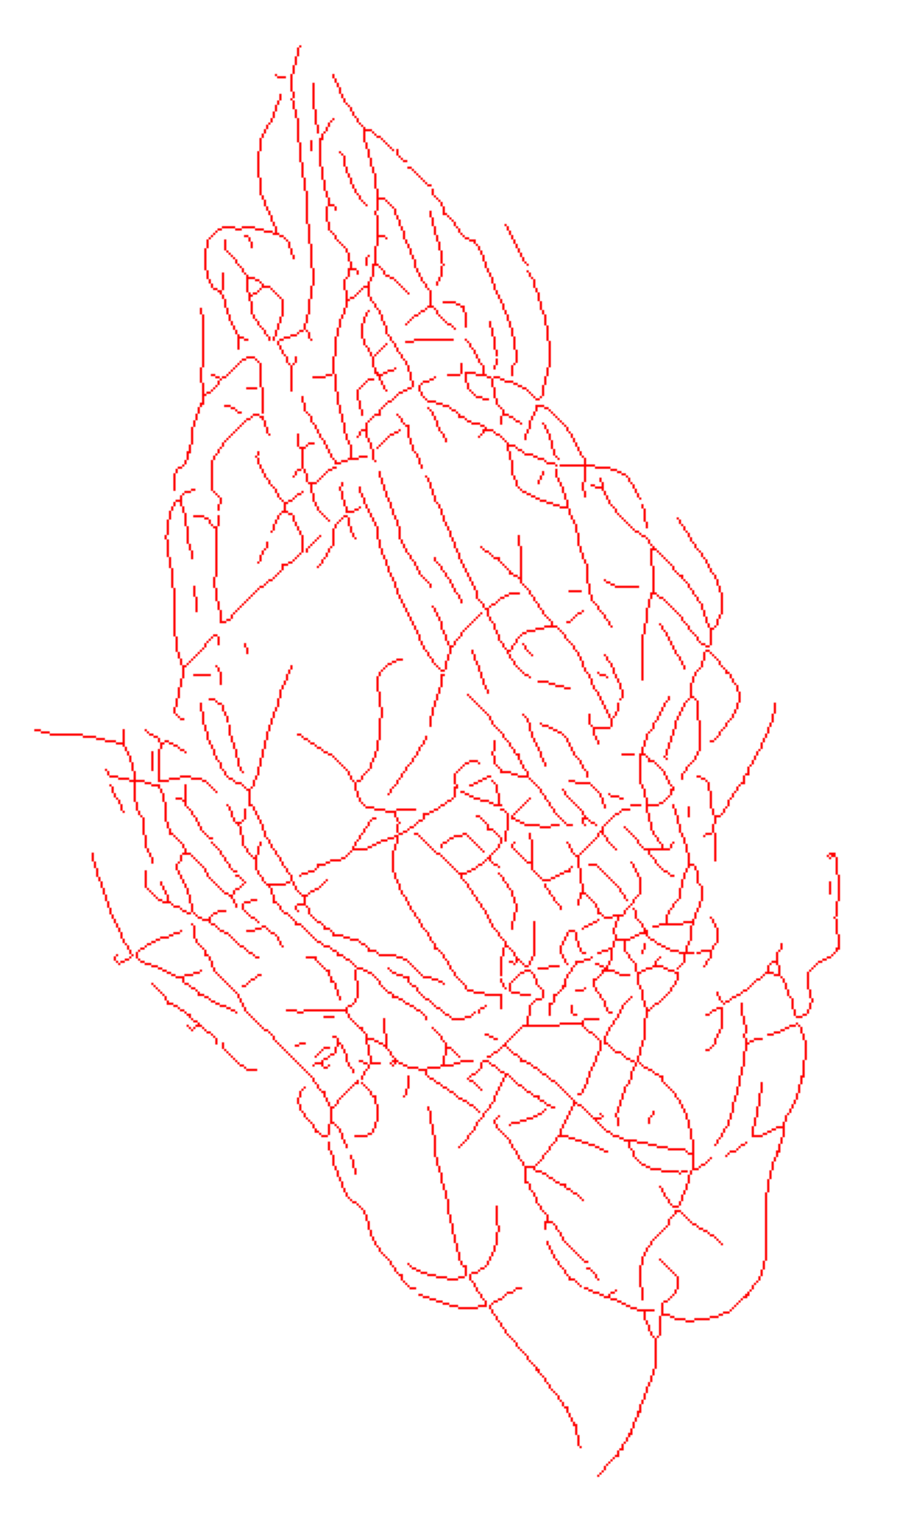

In [46]:
from matplotlib.colors import LinearSegmentedColormap
colors = [(1, 1, 1), (1, 0, 0)] # first color is white, last is red
cm     = LinearSegmentedColormap.from_list("Custom", colors, N=300)
plt.figure(figsize=(15,15))
plt.imshow(imagens[-1],cmap=cm)
plt.axis('off')
plt.tight_layout(pad=0)
plt.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("skelred") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')

NameError: name 'folder' is not defined

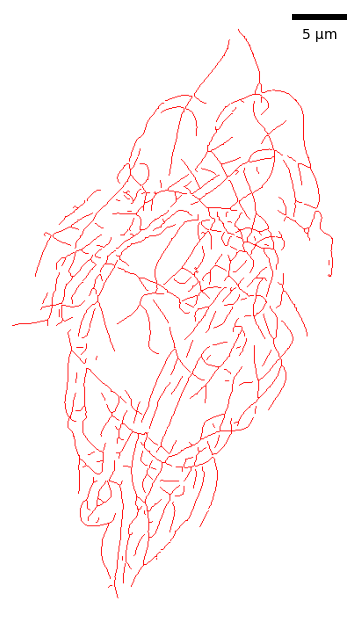

In [38]:
fig_int = intensity_plotter(ResultsRow = ResultsDF.loc[0],
                            data       = data,
                            save       = True)    

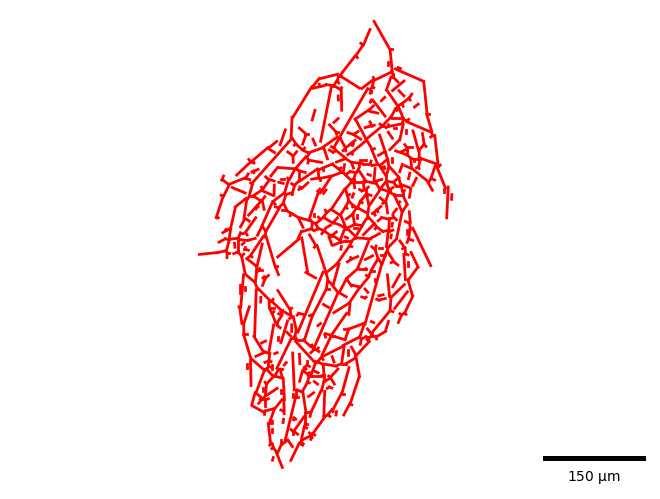

In [6]:
cmap     = pltc.rainbow
cm       = truncate_colormap(cmap, 0, 1, 300)

fig_lines = line_plotter(ResultsRow = ResultsDF.loc[0],
                                 data=data,
                                 feat=None,
                                 cmap=cm,
                                 normalize_bounds=1,
                                 colorbar_label=None,
                                 overlay=True,
                                 save=False)

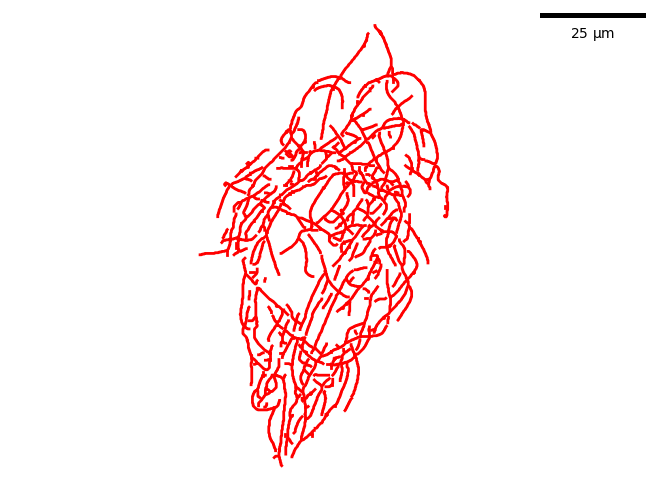

In [6]:
cmap     = pltc.rainbow
cm       = truncate_colormap(cmap, 0, 1, 300)

fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[0],
                          data             = data,
                          feat             = None,
                          cmap             = cm,
                          normalize_bounds = 'default',
                          colorbar_label   = None,
                          nodes            = False,
                          main_branch      = False,
                          overlay          = None,
                          scalebar         = True,
                          save             = "overlay")

---

In [107]:
def read_soax_txt(path):
    import pandas as pd

    # Open the file
    with open(path, 'r') as file:
        lines = file.readlines()

    filament_dataframes = []  # List to store dataframes for each filament
    current_filament_data = []  # List to store data for the current filament

    # Iterate through lines in the file
    for line in lines:
        # Ignore empty lines and lines starting with '#'
        if line.strip() == '' or line.startswith('#'):
            if current_filament_data:
                # Convert current_filament_data to a DataFrame and append it to the list
                df = pd.DataFrame(current_filament_data)
                # Remove the first row from the DataFrame
                df = df.iloc[1:]
                filament_dataframes.append(df)
                current_filament_data = []  # Reset for the next filament
        else:
            # Split the line and append it to the current_filament_data
            data = line.split()
            current_filament_data.append(data)

    # If there's remaining data after the last '#', convert it to a DataFrame and append it
    if current_filament_data:
        df = pd.DataFrame(current_filament_data)
        # Remove the first row from the DataFrame
        df = df.iloc[1:]
        filament_dataframes.append(df)

    # Access individual dataframes
    for i, df in enumerate(filament_dataframes):
        print(f'Filament {i+1} DataFrame:')
        print(df)
        print('\n')
        
    return filament_dataframes

filament_dataframes = read_soax_txt('snakes.txt')

Filament 1 DataFrame:
                                     0      1     2     3     4     5     6   \
1                     intensity-scaling      0  None  None  None  None  None   
2                          gaussian-std      0  None  None  None  None  None   
3                       ridge-threshold   0.01  None  None  None  None  None   
4                    maximum-foreground  65535  None  None  None  None  None   
5                    minimum-foreground      0  None  None  None  None  None   
6                                init-z   true  None  None  None  None  None   
7                   snake-point-spacing      1  None  None  None  None  None   
8                  minimum-snake-length      4  None  None  None  None  None   
9                    maximum-iterations  10000  None  None  None  None  None   
10                     change-threshold    0.1  None  None  None  None  None   
11                         check-period    100  None  None  None  None  None   
12                

     0   1        2        3  4        5        6
1   86   1  340.244  486.009  0  10396.5        0
2   86   2  340.088  486.999  0    12326        0
3   86   3  339.989  487.997  0  16063.2        0
4   86   4  339.871  488.992  0  11383.6        0
5   86   5  339.662  489.973  0  8197.97        0
6   86   6  339.353  490.926  0     9975        0
7   86   7  339.134  491.905  0  13636.5        0
8   86   8  339.036  492.903  0  17692.9        0
9   86   9  338.985  493.904  0  21235.2        0
10  86  10    338.9  494.903  0  14388.5        0
11  86  11  338.707  495.887  0  12418.1        0
12  86  12  338.404  496.842  0  6247.85        0
13  86  13  338.165  497.816  0   8353.7        0
14  86  14  338.032   498.81  0  7784.08        0
15  86  15  337.925  499.807  0  9240.36        0
16  86  16  337.745  500.793  0  8632.52        0
17  86  17   337.48   501.76  0  4490.61        0
18  86  18  337.244  502.734  0  7785.24        0
19  86  19  337.052  503.718  0  10667.8        0


      0   1        2        3  4        5        6
1   184   1  299.922  359.536  0  23459.3        0
2   184   2  300.153  360.501  0  19207.9        0
3   184   3  300.428  361.454  0  11199.3        0
4   184   4  300.722  362.401  0  18505.9        0
5   184   5  301.015  363.349  0    37389        0
6   184   6  301.366  364.277  0  26548.5        0
7   184   7  301.752  365.191  0  35832.3        0
8   184   8  301.993  366.153  0  48100.2        0
9   184   9   302.13  367.136  0  35351.9        0
10  184  10  302.354  368.102  0  22084.6        0
11  184  11  302.689  369.036  0  27200.4        0
12  184  12  302.908  370.004  0    43473        0
13  184  13  303.045  370.986  0  52238.2        0
14  184  14  303.296  371.946  0  31268.1        0
15  184  15  303.678  372.862  0  23095.3        0
16  184  16  304.119  373.751  0  36921.3        0
17  184  17   304.55  374.644  0  22259.5  2204.33
18  184  18  304.898  375.573  0  37560.9  4648.42
19  184  19  305.188  376.522  

In [113]:
filament_dataframes[-1]

,0,1,2,3,4,5,6
1,229,1,67.1682,394.249,0,7190.68,1709.69
2,229,2,67.6633,395.091,0,11472.6,2064.07
3,229,3,68.1594,395.933,0,21622.6,2874.68
4,229,4,68.6341,396.787,0,12501.2,1288.12
5,229,5,69.0932,397.65,0,19050.7,1354.47
...,...,...,...,...,...,...,...
173,"[94.882,","274.876,",0],None,None,None,None
174,"[103.628,","147.802,",0],None,None,None,None
175,"[203.693,","165.043,",0],None,None,None,None
176,"[132.332,","207.158,",0],None,None,None,None


In [119]:
def read_junctions():
    import pandas as pd

    # Read the file line-by-line and reverse the order
    with open('snakes.txt', 'r') as file:
        lines = file.readlines()[::-1]

    # Collect lines that contain lists and stop when the pattern no longer matches
    coordinate_lines = []
    for line in lines:
        line = line.strip()
        # Check if line looks like a list (starts and ends with square brackets)
        if line.startswith('[') and line.endswith(']'):
            coordinate_lines.append(line)
        else:
            break

    # Reverse the list to restore the original order and create a DataFrame
    coordinate_lines.reverse()
    junctionsdf = pd.DataFrame([eval(line) for line in coordinate_lines], columns=['X', 'Y', 'Z'])

    return junctionsdf

junctionsdf = read_junctions()

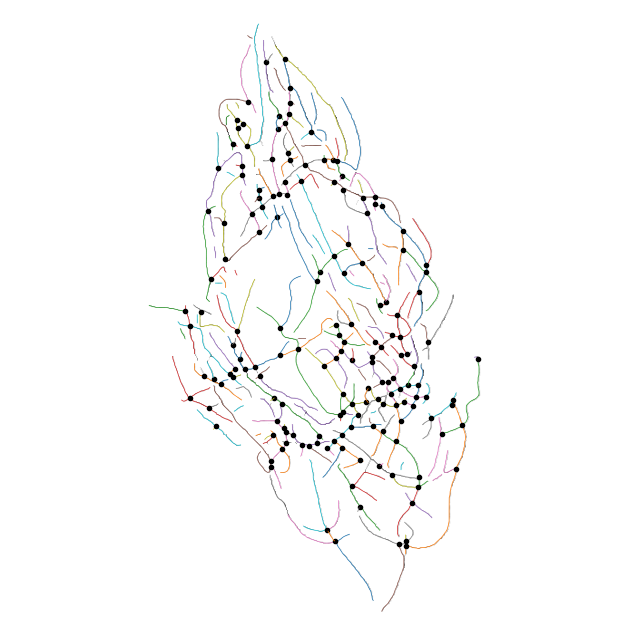

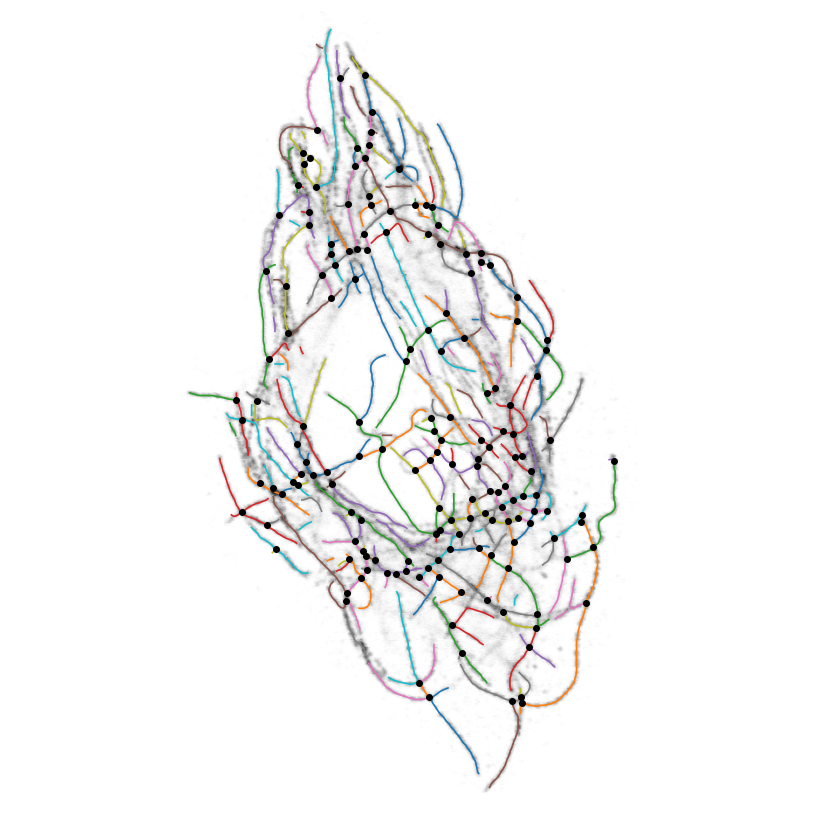

In [137]:
def plot_soax(imgorig,skel,filament_df,junctionsdf):
    
    fig,ax = plt.subplots(figsize=(8,8))
    fig2,ax2 = plt.subplots(figsize=(8,8))
    ax.imshow(np.max(skel)-skel,cmap='gray',alpha=1,zorder=1)
    ax2.imshow(imgorig,cmap='gray')
    ax.axis('off')
    ax2.axis('off')
    ax.axis('equal')
    ax2.axis('equal')
    
    zorder = 2
    # PLOT FILAMENT
    for filament in filament_df[2:-1]:
        x = []
        y = []
        x = [float(a) for a in filament[2]] 
        y = [float(b) for b in filament[3]]
            
        
        ax.plot(x,y,linewidth=0.5,zorder=zorder)
        ax2.plot(x,y,linewidth=1.2,zorder=zorder)
        zorder += 1
    
    # PLOT JUNCTION
    for index,row in junctionsdf.iterrows():
        ax.plot(row[0],row[1],'ko',zorder=200,markersize=3)
        ax2.plot(row[0],row[1],'ko',zorder=300,markersize=4)
    
    plt.tight_layout(pad=0)
    fig.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("skelsoax") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
    fig2.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("origsoax") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
    
    
    
    plt.show()
                    

plot_soax(np.max(imagens[0]) - imagens[0][180:860,0:400],skelorig,filament_dataframes,junctionsdf)

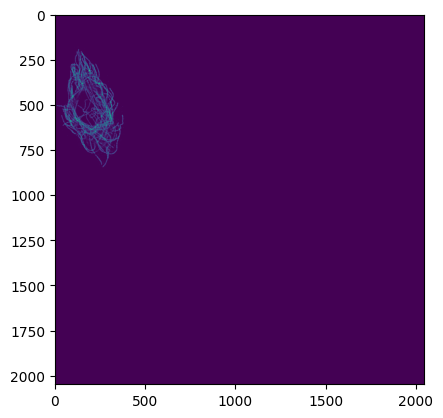

In [93]:
plt.imshow(imagens[0])